## Approach 1: use ATACseq peaks as features for chromatin mods

In [ ]:
# get only peaks that are in both replicates for each timepoint, and take the peak from the first replicate
# peaks must overlap by at least half  
! parallel -j 8 "bedtools intersect -a 633_BRQ{}_rep1_ATACseq_peaks.narrowPeak \
-b 633_BRQ{}_rep2_ATACseq_peaks.narrowPeak -f 0.5 -r -wa > 633_BRQ{}_peaks_comb.bed" ::: 0 12 24 48
! parallel -j 8 "bedtools intersect -a 633_E2wd{}_rep1_ATACseq_peaks.narrowPeak \
-b 633_E2wd{}_rep2_ATACseq_peaks.narrowPeak -f 0.5 -r -wa > 633_E2wd{}_peaks_comb.bed" ::: 0 12 24 48 72 96 120

# make a single file of all peaks, disallowing 50bp overlap
! cat *_peaks_comb.bed | sort -k1,1 -k2,2n | bedtools merge -i - -d 50 > ../../intermediate_files/633_all_peaks.bed
! awk 'BEGIN {{OFS="\t"; print("GeneID", "Chr", "Start", "End", "Strand")}}; \
      {{print("peak" NR,$1,$2,$3,"+")}}' ../../intermediate_files/633_all_peaks.bed > \
      ../../intermediate_files/633_all_peaks.saf

# featureCounts
# -p is paired-end, -T is threads, -O is allowing multi overlap, -M is a multimapper, 
# --fraction relates to both -M and -O
! featureCounts -T 10 -p -O -M --fraction -F SAF -a \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/intermediate_files/633_all_peaks.saf \
-o 220219_atac_k27ac_k4me1_counts.txt \
/net/rowley/ifs/data/vanderheiden/briando/files/210922Van/results/bowtie2_bam/633_DMSO24_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210922Van/results/bowtie2_bam/633_DMSO24_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210922Van/results/bowtie2_bam/633_BRQ24_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210922Van/results/bowtie2_bam/633_BRQ24_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210922Van/results/bowtie2_bam/633_E2wd24_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210922Van/results/bowtie2_bam/633_E2wd24_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_BRQ0_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_BRQ0_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_BRQ24_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_BRQ24_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_BRQ48_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_BRQ48_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_E2wd24_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_E2wd24_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_E2wd48_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/633_E2wd48_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210924Van/results/bowtie2_bam/BD266_DMSO24_H3K27ac_aligned_sorted.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210924Van/results/bowtie2_bam/BD266_BRQ24_H3K27ac_aligned_sorted.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/210924Van/results/bowtie2_bam/BD266_E2wd24_H3K27ac_aligned_sorted.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/211201Van/results/bowtie2_bam/H3K27ac_mp07-360_DMSO_aligned_sorted_rmdup.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/211201Van/results/bowtie2_bam/H3K27ac_mp07-360_BRQ24_aligned_sorted_rmdup.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/211201Van/results/bowtie2_bam/H3K27ac_mp07-360_E2wd24_aligned_sorted_rmdup.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/63.3_DMSO_H3K4me1_aligned_sorted.bam

In [3]:
setwd("~/Dropbox (MIT)/MVH_Code/brq/code")
df = read.table("../data/220219_atac_k27ac_k4me1_counts.txt", header = TRUE, row.names=1)
peak_info = df[,1:5]
df = df[,6:dim(df)[2]]
colnames(df) = c("d24_newatac_r1", "d24_newatac_r2", "b24_newatac_r1", "b24_newatac_r2", "e24_newatac_r1", "e24_newatac_r2",
                 "b0_oldatac_r1", "b0_oldatac_r2", "b24_oldatac_r1", "b24_oldatac_r2", "b48_oldatac_r1", "b48_oldatac_r2",
                 "e24_oldatac_r1", "e24_oldatac_r2", "e48_oldatac_r1", "e48_oldatac_r2", "d24_k27ac", "b24_k27ac", "e24_k27ac",
                 "d24_newk27ac", "b24_newk27ac", "e24_newk27ac", "d24_k4me1")
head(df)

,d24_newatac_r1,d24_newatac_r2,b24_newatac_r1,b24_newatac_r2,e24_newatac_r1,e24_newatac_r2,b0_oldatac_r1,b0_oldatac_r2,b24_oldatac_r1,b24_oldatac_r2,⋯,e24_oldatac_r2,e48_oldatac_r1,e48_oldatac_r2,d24_k27ac,b24_k27ac,e24_k27ac,d24_newk27ac,b24_newk27ac,e24_newk27ac,d24_k4me1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
peak1,5,2,27,27,7,7,9,13,22,14,⋯,7,3,8,2,2,1,1,2,0,3
peak2,26,30,70,116,48,35,50,44,66,22,⋯,92,63,57,10,14,6,8,13,14,7
peak3,29,54,108,151,68,34,95,98,104,37,⋯,156,119,130,8,22,14,13,17,18,15
peak4,13,15,63,97,7,9,17,18,72,38,⋯,14,14,15,5,14,4,3,11,4,33
peak5,1,3,12,22,6,5,10,7,15,8,⋯,16,9,12,2,3,1,1,0,3,5
peak6,4,8,39,59,8,4,29,31,80,42,⋯,34,25,28,6,8,9,8,7,9,23


In [19]:
# differential peaks
d0 <- DGEList(df[,7:16])
d0 <- calcNormFactors(d0, method="TMM")
cutoff <- 3
drop <- which(apply(cpm(d0), 1, max) < cutoff)
d <- d0[-drop,] 
dim(d) # number of genes left

[1] 83280    10

In [20]:
# conditions for differential peak calling
conds = as.character(sapply(names(df[,7:16]), function(x) strsplit(x,'_')[[1]][1]))
conds

# normalize
mm <- model.matrix(~0 + conds)
y <- voom(d, mm, plot = F)
fit <- lmFit(y, mm)
head(coef(fit))

[1] "b0"  "b0"  "b24" "b24" "b48" "b48" "e24" "e24" "e48" "e48"

,condsb0,condsb24,condsb48,condse24,condse48
peak1,0.02944299,1.053889,1.630446,-0.20286196,-0.8604897
peak2,2.07726460,2.341118,2.508595,2.94662853,2.5829295
peak3,3.11580274,3.012033,2.728797,3.81857055,3.6351375
peak4,0.68554992,2.670547,3.028070,0.69671567,0.5762104
peak6,1.44667385,2.819562,3.119932,1.58965966,1.4242832
peak8,-0.32205841,1.007230,1.823031,0.07499903,0.4228177


In [21]:
# get differentially accessible peaks for each condition
process_res = function(res) {
    tmp <- contrasts.fit(fit, res)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    return(res)
}

e24_dep = process_res(makeContrasts("condse24 - condsb0", levels = colnames(coef(fit))))
e48_dep = process_res(makeContrasts("condse48 - condsb0", levels = colnames(coef(fit))))

b24_dep = process_res(makeContrasts("condsb24 - condsb0", levels = colnames(coef(fit))))
b48_dep = process_res(makeContrasts("condsb48 - condsb0", levels = colnames(coef(fit))))

## GREAT analysis

In [4]:
# Normalized values for everything
df_summ = read.table("../data/220219_atac_k27ac_k4me1_counts.txt.summary", header=T, row.names=1)
df_librarysize = apply(df_summ,2,sum)

# normalize by library size, multiply by 1 million
df_norm_lb = sweep(df, 2, df_librarysize, `/`) * 1e6

# normalize by bp of peak size, multiply by 1000
df_norm = sweep(df_norm_lb, 1, peak_info$Length, `/`) * 1e3
head(df_norm)

,d24_newatac_r1,d24_newatac_r2,b24_newatac_r1,b24_newatac_r2,e24_newatac_r1,e24_newatac_r2,b0_oldatac_r1,b0_oldatac_r2,b24_oldatac_r1,b24_oldatac_r2,⋯,e24_oldatac_r2,e48_oldatac_r1,e48_oldatac_r2,d24_k27ac,b24_k27ac,e24_k27ac,d24_newk27ac,b24_newk27ac,e24_newk27ac,d24_k4me1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
peak1,0.9720918,0.3933005,2.163339,1.680317,1.0577041,1.3866826,0.9463778,1.1404625,1.947184,2.570825,⋯,0.7313685,0.3724435,0.9268732,0.4196892,0.3728682,0.1884329,0.2958964,0.5967265,0.0000000,0.2550507
peak2,4.8604591,5.6726036,5.392939,6.941482,6.9738732,6.6667432,5.0554370,3.7115644,5.616877,3.884488,⋯,9.2425695,7.5204938,6.3499729,2.0177366,2.5096896,1.0871128,2.2761260,3.7295409,3.1820816,0.5722291
peak3,5.5712773,10.4931957,8.550747,9.285899,10.1530038,6.6554500,9.8710905,8.4953882,9.095721,6.713758,⋯,16.1058008,14.5984113,14.8830930,1.6588507,4.0529149,2.6067789,3.8010404,5.0120312,4.2044444,1.2601319
peak4,1.5582236,1.8185906,3.112078,3.721761,0.6520987,1.0991847,1.1020977,0.9735524,3.928854,4.302068,⋯,0.9018108,1.0715596,1.0714472,0.6468699,1.6091721,0.4646927,0.5472806,2.0234254,0.5829426,1.7296903
peak5,0.3251143,0.9865398,1.607833,2.289544,1.5160594,1.6563337,1.7584129,1.0269151,2.220109,2.456593,⋯,2.7954842,1.8684457,2.3249329,0.7018214,0.9352881,0.3151051,0.4948100,0.0000000,1.1858689,0.7108436
peak6,0.6797845,1.3751766,2.731489,3.209619,1.0566475,0.6926486,2.6655941,2.3772417,6.189396,6.741674,⋯,3.1052111,2.7130208,2.8357136,1.1005836,1.3037349,1.4824265,2.0692054,1.8256494,1.8596581,1.7092558


In [404]:
# correlations between replicates for old and new atac
cor(log10(df_norm$d24_newatac_r1+0.1), log10(df_norm$d24_newatac_r2+0.1))
cor(log10(df_norm$b24_newatac_r1+0.1), log10(df_norm$b24_newatac_r2+0.1))
cor(log10(df_norm$e24_newatac_r1+0.1), log10(df_norm$e24_newatac_r2+0.1))
cor(log10(df_norm$b0_oldatac_r1+0.1), log10(df_norm$b0_oldatac_r2+0.1))
cor(log10(df_norm$b24_oldatac_r1+0.1), log10(df_norm$b24_oldatac_r2+0.1))
cor(log10(df_norm$e24_oldatac_r1+0.1), log10(df_norm$e24_oldatac_r2+0.1))
cor(log10(df_norm$b48_oldatac_r1+0.1), log10(df_norm$b48_oldatac_r2+0.1))
cor(log10(df_norm$e48_oldatac_r1+0.1), log10(df_norm$e48_oldatac_r2+0.1))

[1] 0.8318438

[1] 0.9500165

[1] 0.847072

[1] 0.9421489

[1] 0.9051059

[1] 0.9378032

[1] 0.9487631

[1] 0.9391027

In [405]:
# correlations between old atac and new atac for each timepoint, combining replicates
cor(log10(df_norm$b0_oldatac_r1+0.1) + log10(df_norm$b0_oldatac_r2+0.1),
    log10(df_norm$d24_newatac_r1+0.1) + log10(df_norm$d24_newatac_r2+0.1))
cor(log10(df_norm$b24_oldatac_r1+0.1) + log10(df_norm$b24_oldatac_r2+0.1),
    log10(df_norm$b24_newatac_r1+0.1) + log10(df_norm$b24_newatac_r2+0.1))
cor(log10(df_norm$e24_oldatac_r1+0.1) + log10(df_norm$e24_oldatac_r2+0.1),
    log10(df_norm$e24_newatac_r1+0.1) + log10(df_norm$e24_newatac_r2+0.1))

[1] 0.7827008

[1] 0.7751768

[1] 0.7990107

In [403]:
# correlations between old k27ac and new k27ac
cor(log10(df_norm$d24_k27ac + 0.1), log10(df_norm$d24_newk27ac + 0.1))
cor(log10(df_norm$b24_k27ac + 0.1), log10(df_norm$b24_newk27ac + 0.1))
cor(log10(df_norm$e24_k27ac + 0.1), log10(df_norm$e24_newk27ac + 0.1))

[1] 0.7549807

[1] 0.8052524

[1] 0.7747727

In [5]:
# combine replicates from atacs done at the same time
df_norm_atac_comb = (df_norm[,(seq(1,8) * 2 - 1)] + df_norm[,(seq(1,8) * 2)])/2
colnames(df_norm_atac_comb) = gsub("_r1", "", colnames(df_norm_atac_comb))
df_norm_comb = cbind(df_norm_atac_comb, df_norm[,17:dim(df_norm)[2]])
head(df_norm_comb)

,d24_newatac,b24_newatac,e24_newatac,b0_oldatac,b24_oldatac,b48_oldatac,e24_oldatac,e48_oldatac,d24_k27ac,b24_k27ac,e24_k27ac,d24_newk27ac,b24_newk27ac,e24_newk27ac,d24_k4me1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
peak1,0.6826962,1.921828,1.2221933,1.043420,2.259004,3.235055,1.015538,0.6496584,0.4196892,0.3728682,0.1884329,0.2958964,0.5967265,0.0000000,0.2550507
peak2,5.2665314,6.167211,6.8203082,4.383501,4.750683,5.743646,8.734941,6.9352333,2.0177366,2.5096896,1.0871128,2.2761260,3.7295409,3.1820816,0.5722291
peak3,8.0322365,8.918323,8.4042269,9.183239,7.904739,6.895445,16.454334,14.7407521,1.6588507,4.0529149,2.6067789,3.8010404,5.0120312,4.2044444,1.2601319
peak4,1.6884071,3.416919,0.8756417,1.037825,4.115461,5.293545,1.185430,1.0715034,0.6468699,1.6091721,0.4646927,0.5472806,2.0234254,0.5829426,1.7296903
peak5,0.6558270,1.948689,1.5861966,1.392664,2.338351,3.958562,2.937250,2.0966893,0.7018214,0.9352881,0.3151051,0.4948100,0.0000000,1.1858689,0.7108436
peak6,1.0274806,2.970554,0.8746480,2.521418,6.465535,7.980494,3.067416,2.7743672,1.1005836,1.3037349,1.4824265,2.0692054,1.8256494,1.8596581,1.7092558


In [6]:
# make a list of peaks with >25% ATAC signal at some point during treatment, and >25% K4me1 signal for GREAT
toldatac = as.numeric(quantile(df_norm_comb$b0_oldatac, 0.25))
tk4me1 = as.numeric(quantile(df_norm_comb$d24_k4me1, 0.25))

df_norm_comb_hi = subset(df_norm_comb, (apply(df_norm_comb[,4:8], 1, max) > toldatac) &
                                               df_norm_comb$d24_k4me1 > tk4me1)
dim(df_norm_comb_hi)

[1] 91670    15

In [7]:
# make bed file for GREAT
df_norm_comb_hi_bed = peak_info[rownames(df_norm_comb_hi),]
df_norm_comb_hi_bed = cbind(df_norm_comb_hi_bed[,1:3], rownames(df_norm_comb_hi_bed), df_norm_comb_hi_bed$Length, df_norm_comb_hi_bed$Strand)
head(df_norm_comb_hi_bed)
#write.table(df_norm_comb_hi_bed, file = "../output/220220_633_atac_k4me1hi.bed", quote = F, col.names=F, row.names=F)

,Chr,Start,End,rownames(df_norm_comb_hi_bed),df_norm_comb_hi_bed$Length,df_norm_comb_hi_bed$Strand
,<chr>,<int>,<int>,<chr>,<int>,<chr>
peak3,chr1,3059480,3059985,peak3,506,+
peak4,chr1,3083075,3083885,peak4,811,+
peak6,chr1,3104799,3105370,peak6,572,+
peak7,chr1,3220732,3221035,peak7,304,+
peak10,chr1,3365821,3366127,peak10,307,+
peak12,chr1,3382454,3383060,peak12,607,+


In [8]:
# processing region-gene associations from GREAT (50kb)
# great_data = read.table("../data/20220220-public-4.0.4-hlnHpD-mm10-all-region.txt", sep='\t')  # 50kb
great_data = read.table("../data/20220409-public-4.0.4-oVg2kC-mm10-all-region.txt", sep='\t')  # 100kb



great_data = great_data[great_data$V2 != "NONE",]
great_data$gene = sapply(great_data$V2, function(x) strsplit(x, split = ' ')[[1]][1])
great_data$dist = sapply(great_data$V2, function(x) strsplit(x, split = ' ')[[1]][2])
great_data$dist = as.numeric(gsub('(', '', gsub(')', '', great_data$dist, fixed=T), fixed=T))
rownames(great_data) = great_data$V1
colnames(great_data) = c("peak_id", "great_output", "gene", "dist")
head(great_data)

,peak_id,great_output,gene,dist
,<chr>,<chr>,<chr>,<dbl>
peak23,peak23,Rp1 (-54087),Rp1,-54087
peak24,peak24,Rp1 (-54570),Rp1,-54570
peak25,peak25,Rp1 (-56588),Rp1,-56588
peak26,peak26,Rp1 (-57835),Rp1,-57835
peak31,peak31,Sox17 (+28008),Sox17,28008
peak34,peak34,Sox17 (-75406),Sox17,-75406


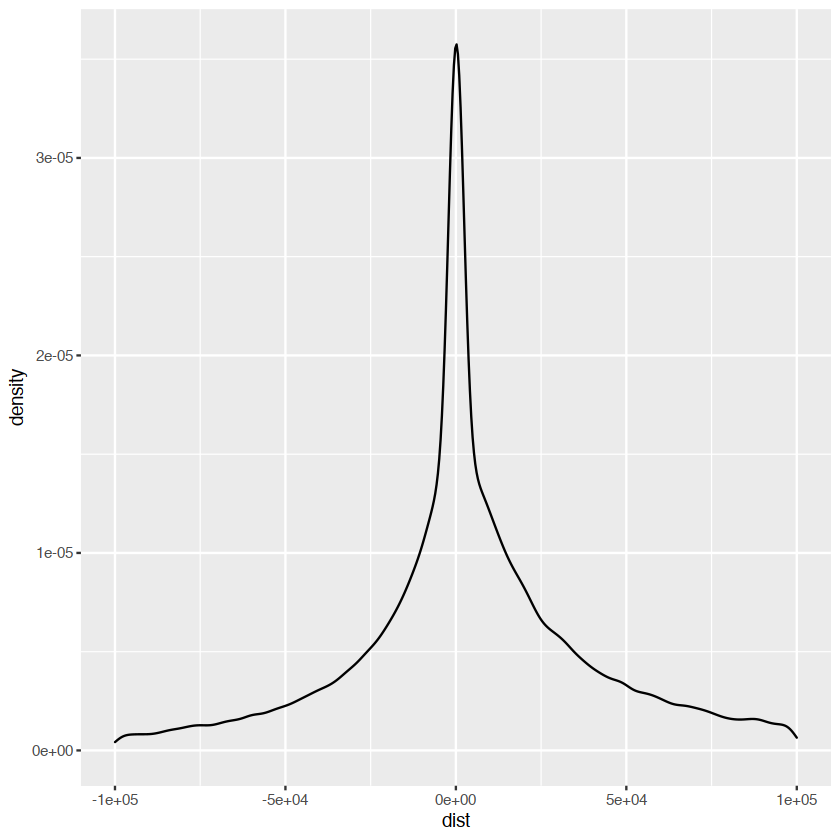

In [13]:
# distance of peaks from TSS
ggplot(great_data, aes(x=dist)) + geom_density()

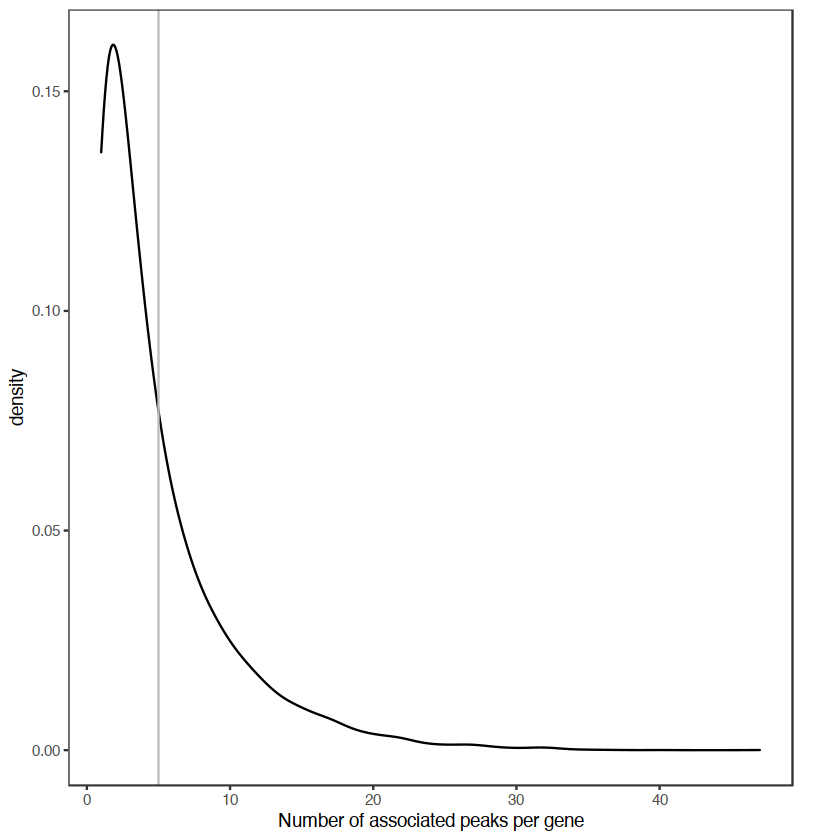

In [14]:
# number of regions per gene
counts = great_data %>% count(gene)
rownames(counts) = counts$gene
ggplot(counts, aes(x=n)) + geom_density(adjust=2) +
geom_vline(xintercept=5, color="gray") + xlab("Number of associated peaks per gene") +
           theme_bw() + theme(panel.grid.major = element_blank(), 
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0.2,1,0.2,0.2), "cm"))
#ggsave("../output/220221_num_peaks.pdf", width=3, height=2.5) 

In [15]:
# high complexity genes -- top tertile
z = as.numeric(quantile(counts$n, 0.666))
z = 3
print(z)
counts_high = subset(counts, n >= z)
dim(counts_high)

[1] 3


[1] 9674    2

In [16]:
# get rnaseq LFCs
rnaseq = read.csv("../data/210421_633_brq_e2w_rnaseq_log_cpm.csv", sep=' ')
rnaseq$b12_rna_lfc = with(rnaseq, (BRQ_12h_rep1 + BRQ_12h_rep2 - BRQ_0h_rep1 - BRQ_0h_rep2)/2)
rnaseq$b24_rna_lfc = with(rnaseq, (BRQ_24h_rep1 + BRQ_24h_rep2 - BRQ_0h_rep1 - BRQ_0h_rep2)/2)
rnaseq$b48_rna_lfc = with(rnaseq, (BRQ_48h_rep1 + BRQ_48h_rep2 - BRQ_0h_rep1 - BRQ_0h_rep2)/2)
rnaseq$b72_rna_lfc = with(rnaseq, (BRQ_72h_rep1 + BRQ_72h_rep2 - BRQ_0h_rep1 - BRQ_0h_rep2)/2)
rnaseq$b96_rna_lfc = with(rnaseq, (BRQ_96h_rep1 + BRQ_96h_rep2 - BRQ_0h_rep1 - BRQ_0h_rep2)/2)

rnaseq$e12_rna_lfc = with(rnaseq, (X633_E2w_12h_rep1 + X633_E2w_12h_rep2 - X633_E2w_0h_rep1 - X633_E2w_0h_rep2)/2)
rnaseq$e24_rna_lfc = with(rnaseq, (X633_E2w_24h_rep1 + X633_E2w_24h_rep2 - X633_E2w_0h_rep1 - X633_E2w_0h_rep2)/2)
rnaseq$e48_rna_lfc = with(rnaseq, (X633_E2w_48h_rep1 + X633_E2w_48h_rep2 - X633_E2w_0h_rep1 - X633_E2w_0h_rep2)/2)
rnaseq$e72_rna_lfc = with(rnaseq, (X633_E2w_72h_rep1 + X633_E2w_72h_rep2 - X633_E2w_0h_rep1 - X633_E2w_0h_rep2)/2)
rnaseq$e96_rna_lfc = with(rnaseq, (X633_E2w_96h_rep1 + X633_E2w_96h_rep2 - X633_E2w_0h_rep1 - X633_E2w_0h_rep2)/2)

rnaseq_lfc = rnaseq[,(dim(rnaseq)[2]-9):dim(rnaseq)[2]]
rnaseq_lfc = rnaseq_lfc[which(rownames(rnaseq_lfc) %in% counts$gene), ]
rnaseq_lfc_hicomplexity = rnaseq_lfc[which(rownames(rnaseq_lfc) %in% counts_high$gene), ]

dim(rnaseq_lfc)
dim(rnaseq_lfc_hicomplexity)
head(rnaseq_lfc)


[1] 10309    10

[1] 6767   10

,b12_rna_lfc,b24_rna_lfc,b48_rna_lfc,b72_rna_lfc,b96_rna_lfc,e12_rna_lfc,e24_rna_lfc,e48_rna_lfc,e72_rna_lfc,e96_rna_lfc
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mrpl15,-0.9955099,-1.1318480,-1.2682394,-0.8776146,-0.70880737,-0.18468559,0.08634160,-0.41040898,-1.0041075,-1.71593153
Lypla1,-0.1245629,-0.5936585,-0.7945488,-0.7450447,-0.41397765,-0.14000395,0.07363891,0.02918566,0.1026270,-0.02322627
Tcea1,-0.5321909,-0.8718922,-0.8228871,-0.5474073,-0.39441481,-0.27640411,-0.03922160,-0.41055855,-0.7156555,-0.77986378
Atp6v1h,-0.3179183,-0.5723272,-0.5214369,-0.1816442,-0.03236369,0.08881129,0.32637256,0.22436544,0.3154068,0.50753884
Rb1cc1,0.3334993,0.1877118,0.3519116,0.4745381,0.41803500,-0.26319818,0.03670696,0.20776104,0.4320050,0.76569044
St18,1.6542243,3.0631038,3.3269802,2.5693982,1.32266938,0.73654923,0.09468603,1.64568596,2.3429207,3.51378657


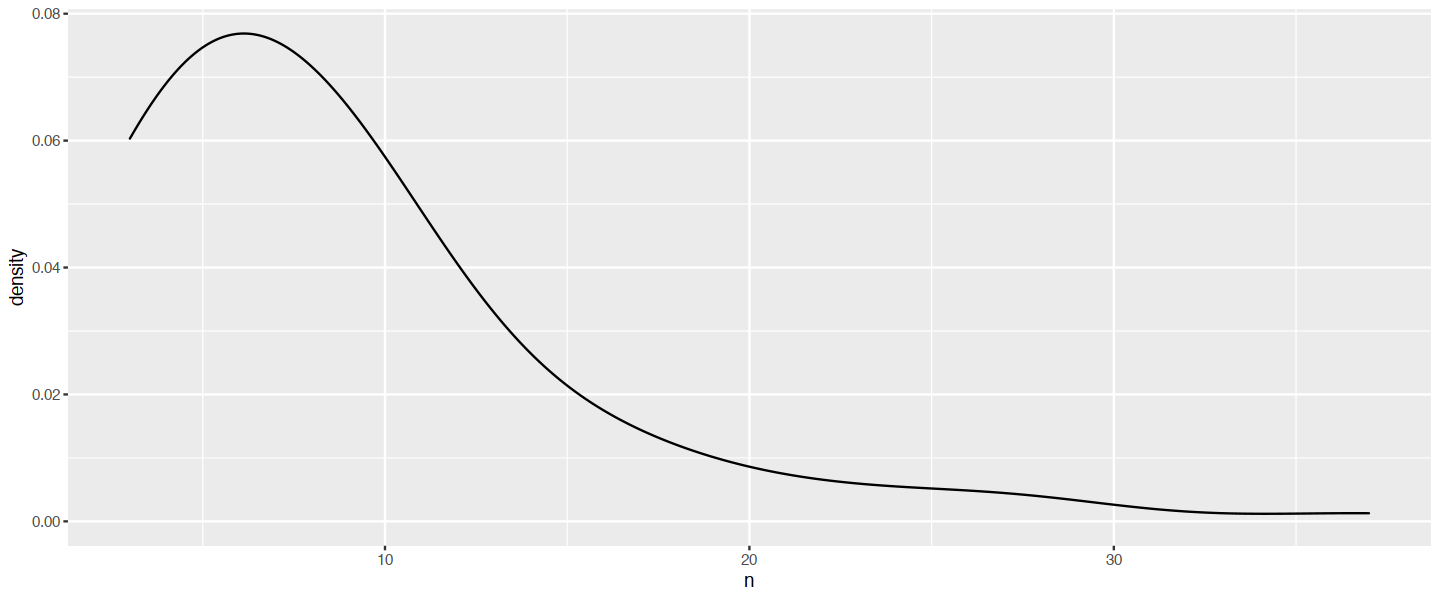

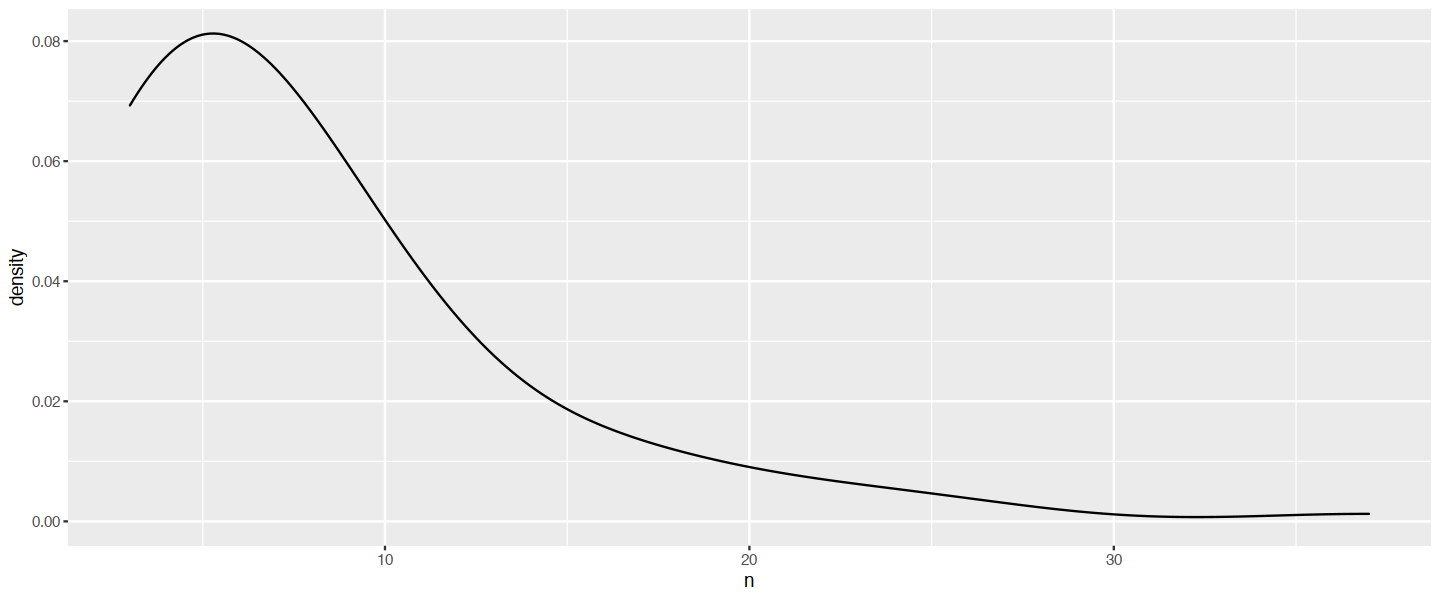

In [49]:
# top 100 BRQ and LFC genes, and associated numbers of peaks 
z = rownames(rnaseq_lfc_hicomplexity[order(-rnaseq_lfc_hicomplexity$b48_rna_lfc), ][1:100,])
ggplot(counts[z,], aes(x=n)) + geom_density(adjust=2)
z = rownames(rnaseq_lfc_hicomplexity[order(-rnaseq_lfc_hicomplexity$e48_rna_lfc), ][1:100,])
ggplot(counts[z,], aes(x=n)) + geom_density(adjust=2)


[1] 61639

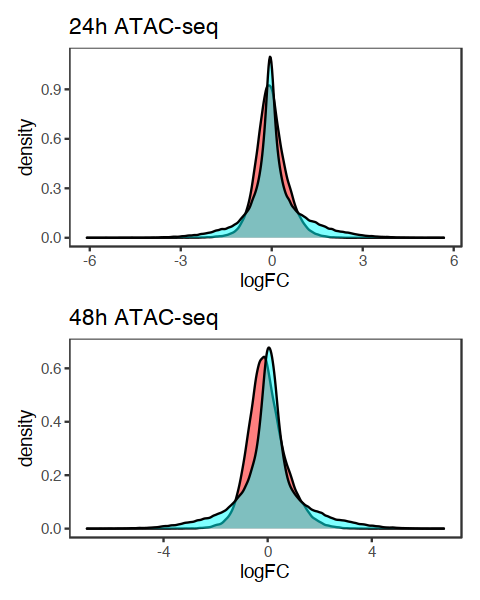

In [22]:
# z is the set of peaks that is ATAC > 25th percentile, K4me1 > 25th percentile, and within 50kb of genes
z = intersect(rownames(b24_dep), rownames(great_data))
length(z)

g1 = ggplot() + geom_density(data = b24_dep[z,], aes(x=logFC), fill="red", alpha=0.5) +
           geom_density(data = e24_dep[z,], aes(x=logFC), fill="cyan", alpha=0.5) + ggtitle("24h ATAC-seq") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

g2 = ggplot() + geom_density(data = b48_dep[z,], aes(x=logFC), fill="red", alpha=0.5) +
           geom_density(data = e48_dep[z,], aes(x=logFC), fill="cyan", alpha=0.5) + ggtitle("48h ATAC-seq") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

options(repr.plot.width=4, repr.plot.height=5)
g1 / g2
#ggsave("../output/220221_peaks_density.pdf", width=4, height=5)

## 48h shared upregulated genes

In [24]:
b48_great_upreg$activity_dist = b48_great_upreg$logFC/abs(b48_great_upreg$dist)
b48_activity_dist = b48_great_upreg %>% group_by(gene) %>% 
        summarize(abc = sum(activity_dist))

e48_great_upreg$activity_dist = e48_great_upreg$logFC/abs(e48_great_upreg$dist)
e48_activity_dist = e48_great_upreg %>% group_by(gene) %>% 
        summarize(abc = sum(activity_dist))

b48_med = b48_great_upreg %>% group_by(gene) %>% 
        summarize(med = median(logFC))

e48_med = e48_great_upreg %>% group_by(gene) %>% 
        summarize(med = median(logFC))

frac_48h = merge(frac_48h, b48_activity_dist, by="gene")
frac_48h = merge(frac_48h, e48_activity_dist, by="gene")
frac_48h = merge(frac_48h, b48_med, by="gene")
frac_48h = merge(frac_48h, e48_med, by="gene")

rownames(frac_48h) = frac_48h$gene
colnames(frac_48h) = c("gene", "b48_frac", "b48_lfc", "e48_frac", "e48_lfc", "b48_abc", "e48_abc", "b48_med", "e48_med")
head(frac_48h)


,gene,b48_frac,b48_lfc,e48_frac,e48_lfc,b48_abc,e48_abc,b48_med,e48_med
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1600014C10Rik,1600014C10Rik,0.5555556,1.663749,0.4444444,2.640576,0.0012705383,0.0005181424,0.2757160,0.2146031
1700012B09Rik,1700012B09Rik,0.4000000,1.676428,0.0000000,1.268348,0.0043442271,-0.0045843102,0.2035357,-0.2029805
2210010C04Rik,2210010C04Rik,0.7058824,5.546468,0.2352941,1.775602,0.0008925368,-0.0002279927,0.7945909,-0.2336073
4930438A08Rik,4930438A08Rik,0.5000000,5.124559,0.6666667,8.228878,-0.0101398848,0.0541487398,0.3575246,1.0614022
4932438H23Rik,4932438H23Rik,0.0000000,2.202084,0.4444444,1.072466,-0.0139396398,-0.0120726549,-0.3463245,0.1808451
6430548M08Rik,6430548M08Rik,0.5000000,3.977599,1.0000000,2.008522,-0.0013982111,0.0025982797,0.6117160,1.1210606


In [85]:
wilcox.test(frac_48h$b48_abc, frac_48h$e48_abc)
wilcox.test(frac_48h$b48_med, frac_48h$e48_med)


	Wilcoxon rank sum test with continuity correction

data:  frac_48h$b48_abc and frac_48h$e48_abc
W = 130923, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  frac_48h$b48_med and frac_48h$e48_med
W = 163960, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


Warning message:
“Removed 63 rows containing non-finite values (stat_density).”
Warning message:
“Removed 84 rows containing non-finite values (stat_density).”


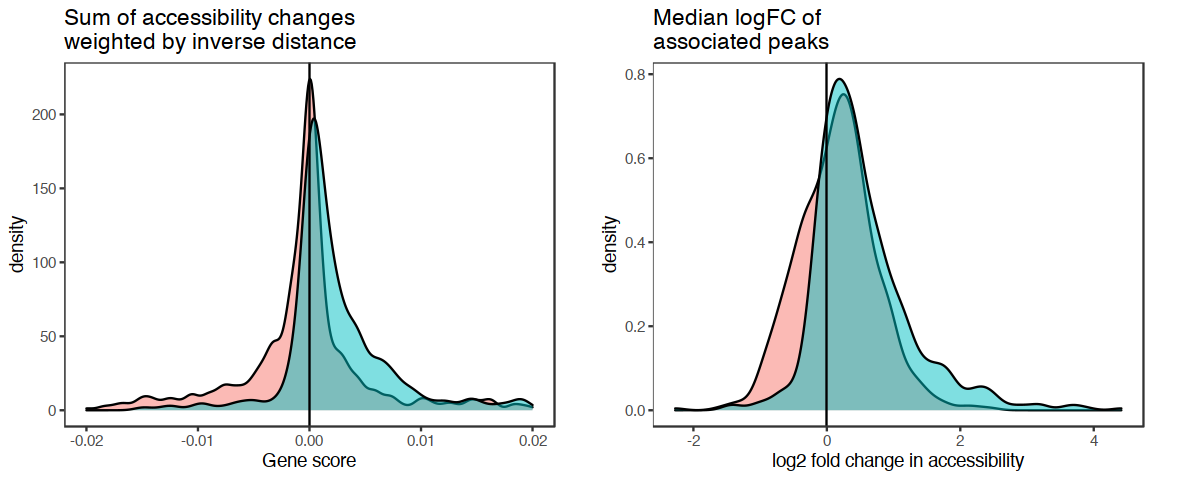

In [86]:
options(repr.plot.width=10, repr.plot.height=4)
g1 = ggplot() + geom_density(data=frac_48h, aes(x=b48_abc), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=e48_abc), fill="#00BFC4", alpha=0.5) +
           ggtitle("Sum of accessibility changes\nweighted by inverse distance") + xlab("Gene score") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm")) + xlim(-0.02, 0.02) + geom_vline(xintercept=0)

g2 = ggplot() + geom_density(data=frac_48h, aes(x=b48_med), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=e48_med), fill="#00BFC4", alpha=0.5) +
           ggtitle("Median logFC of\nassociated peaks") + xlab("log2 fold change in accessibility") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm")) + geom_vline(xintercept=0)
g1 + g2
#ggsave("../output/220221_shared_genes_otherscores.pdf", width=6, height=2.5)


	Wilcoxon rank sum test with continuity correction

data:  b48_frac and e48_frac
W = 151142, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


[1] 0.2727273

[1] 0.5


	Wilcoxon rank sum test with continuity correction

data:  b48_lfc and e48_lfc
W = 259317, p-value = 6.744e-05
alternative hypothesis: true location shift is not equal to 0


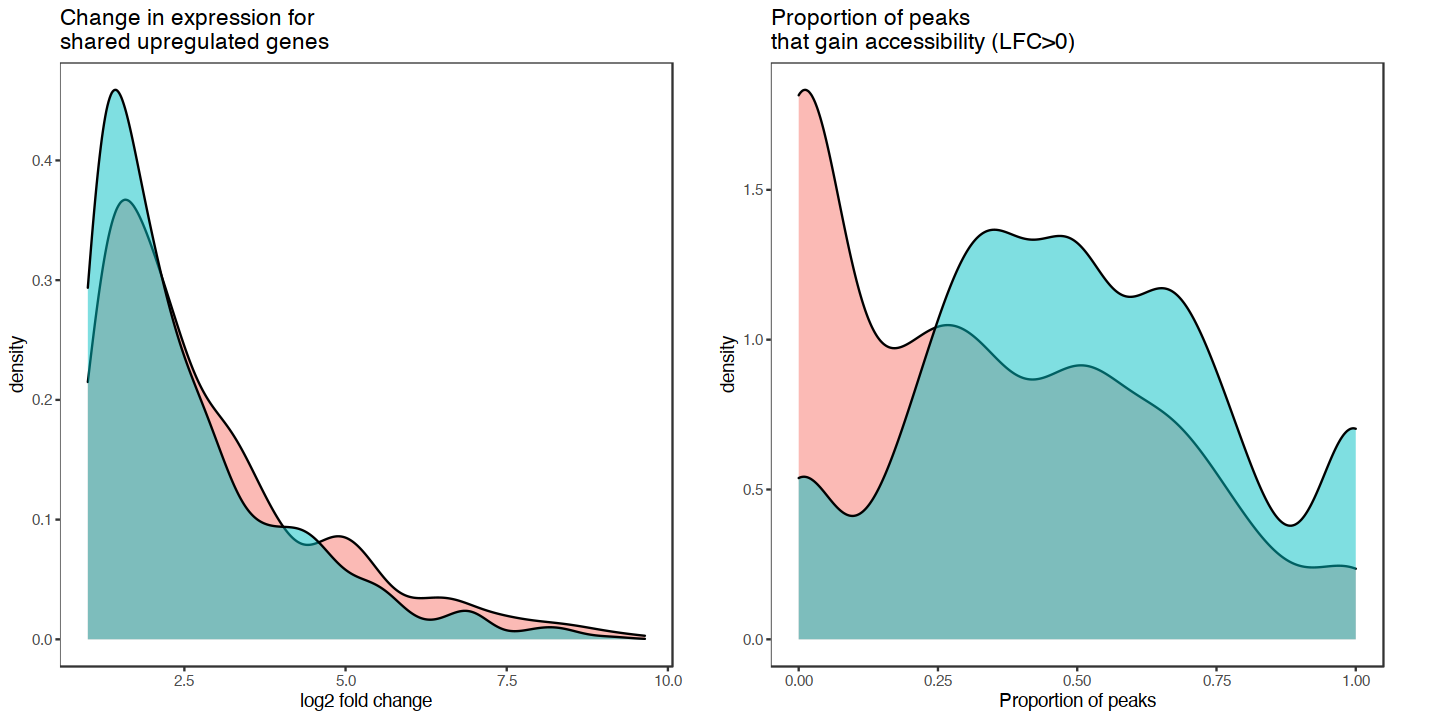

In [87]:
# plotting densities
g1 = ggplot() + geom_density(data=frac_48h, aes(x=b48_frac), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=e48_frac), fill="#00BFC4", alpha=0.5) +
           ggtitle("Proportion of peaks\nthat gain accessibility (LFC>0)") + xlab("Proportion of peaks") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm"))

g2 = ggplot() + geom_density(data=frac_48h, aes(x=b48_lfc), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=e48_lfc), fill="#00BFC4", alpha=0.5) +
           ggtitle("Change in expression for\nshared upregulated genes") + xlab("log2 fold change") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm"))

options(repr.plot.width=12, repr.plot.height=6)
g2 + g1
#ggsave("../output/220220_shared_up_genes_lfc0.pdf", width=6, height=2.5)
# wilcox test 
with(frac_48h, wilcox.test(b48_frac, e48_frac))
median(frac_48h$b48_frac)
median(frac_48h$e48_frac)
with(frac_48h, wilcox.test(b48_lfc, e48_lfc))

In [32]:
frac_48h[order(-frac_48h$e48_frac + frac_48h$b48_frac),]

,gene,b48_frac,b48_lfc,e48_frac,e48_lfc,b48_abc,e48_abc,b48_med,e48_med
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Cnst,Cnst,0.0000000,1.034633,1.0000000,1.592754,-1.409734e-02,0.0068588725,0.4361291421,1.6631269
Cstb,Cstb,0.0000000,1.383041,1.0000000,2.154844,3.297191e-04,0.0013943538,0.0007703565,0.8198054
Dgat2,Dgat2,0.0000000,3.211375,1.0000000,4.184791,-3.216404e-02,0.0289327813,-0.1367611077,1.5885218
Rnd1,Rnd1,0.0000000,3.092767,1.0000000,3.745656,-8.698371e-03,0.0074675609,-0.7264426900,1.8384295
Slc22a4,Slc22a4,0.0000000,2.429636,1.0000000,2.358937,5.465114e-05,0.0073011652,0.0543469827,0.9401523
Sytl3,Sytl3,0.0000000,6.536913,1.0000000,2.343050,-8.420342e-06,0.0003414571,0.0069100706,0.7316328
Sun2,Sun2,0.0000000,2.082979,0.9090909,2.013475,-9.416493e-03,0.0087903715,-0.9464859518,1.1969464
Hexa,Hexa,0.0000000,1.100591,0.8750000,1.107354,-5.428838e-03,0.0062277324,-0.0825443721,1.4784810
Il1b,Il1b,0.0000000,6.200718,0.8571429,1.368892,1.157826e-03,0.0207182278,0.0308505865,1.0033119


Warning message:
“ggrepel: 445 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 458 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


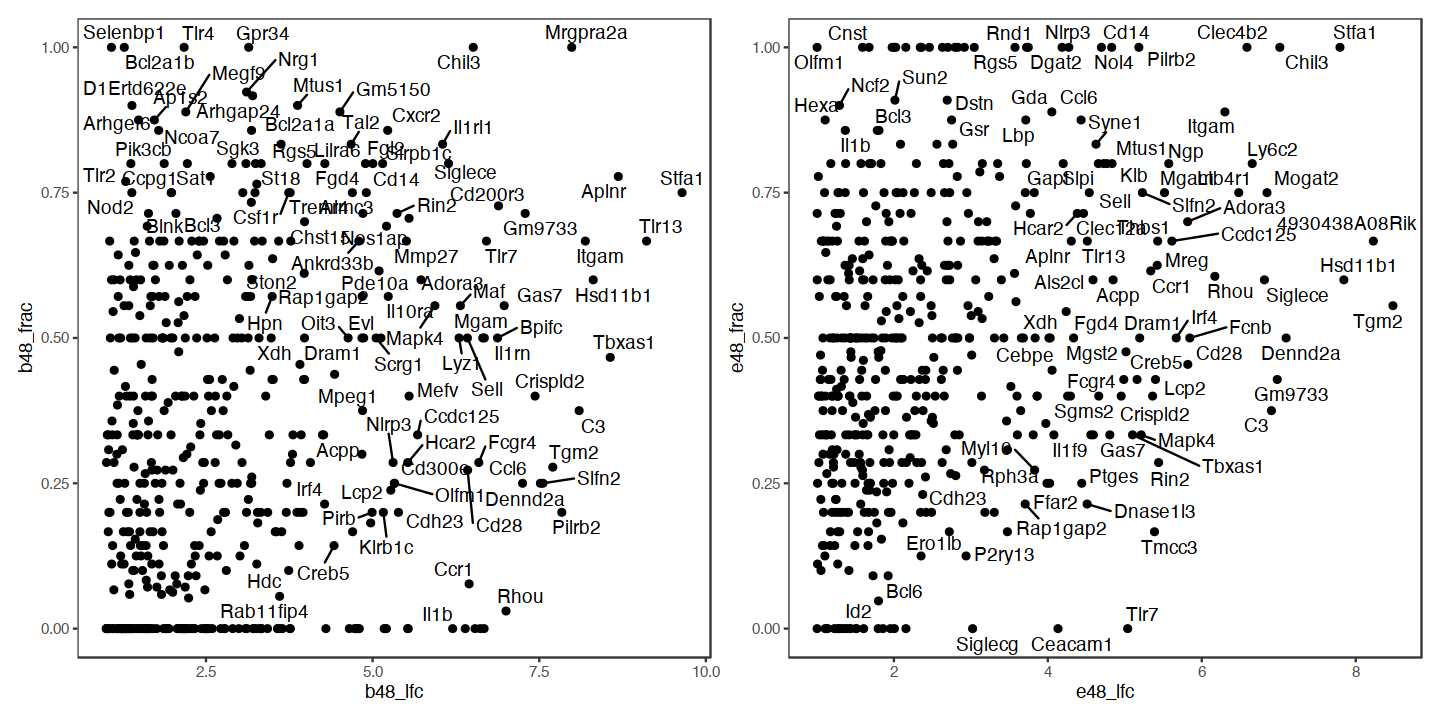

In [34]:
frac_48h$labels = ""
interesting_genes = c("Ccl6", "Nlrp3", "Tlr13", "Stfa1", "Csf2rb", "Alas1", "Slpi", "Lbp", "Tlr7", "Siglecg", "Aplnr")
frac_48h[which(rownames(frac_48h) %in% interesting_genes), ]$labels = rownames(frac_48h[which(rownames(frac_48h) %in% interesting_genes), ])

g1 = ggplot(frac_48h, aes(x=b48_lfc, y=b48_frac, label=gene)) + geom_point() +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank()) +
            geom_text_repel(max.overlaps=10)
g2 = ggplot(frac_48h, aes(x=e48_lfc, y=e48_frac, label=gene)) + geom_point() +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank()) +
            geom_text_repel(max.overlaps=10)

options(repr.plot.width=12, repr.plot.height=6)
(g1 + g2)

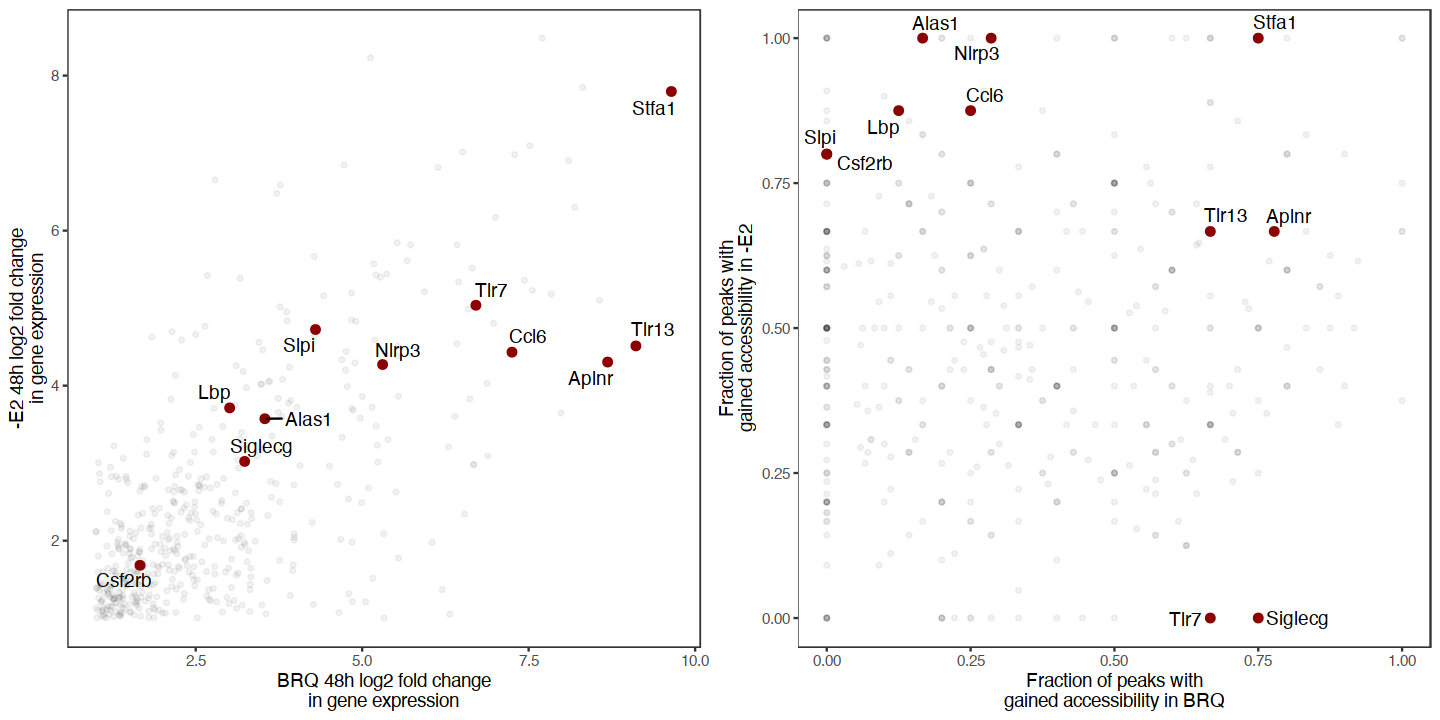

In [35]:
g3 = ggplot(frac_48h, aes(x=b48_lfc, y=e48_lfc)) + geom_point(alpha=0.05, size=1) +
        geom_point(data=subset(frac_48h, labels != ""), color="darkred", size=2) +
        theme_bw() + theme(panel.grid.major = element_blank(),
                           panel.grid.minor = element_blank(),
                           plot.margin = unit(c(0,0.4,0,0), "cm")) +
        geom_text_repel(data=subset(frac_48h, labels != ""), aes(label=labels), 
        max.overlaps=200, force=10) + xlab("BRQ 48h log2 fold change\nin gene expression") +
        ylab("-E2 48h log2 fold change\nin gene expression")
g4 = ggplot(frac_48h, aes(x=b48_frac, y=e48_frac, label=labels)) + geom_point(alpha=0.05, size=1) +
        geom_point(data=subset(frac_48h, labels != ""), color="darkred", size=2) +
        theme_bw() + theme(panel.grid.major = element_blank(),
                            panel.grid.minor = element_blank(),
                           plot.margin = unit(c(0,0,0,0), "cm")) +
        geom_text_repel(data=subset(frac_48h, labels != ""), aes(label=labels),
        max.overlaps=200, force=10) + xlab("Fraction of peaks with\ngained accessibility in BRQ") +
        ylab("Fraction of peaks with\ngained accessibility in -E2")
(g3 + g4)
ggsave("../output/220220_shared_up_genes_scatter.pdf", width=6, height=3)


In [25]:
get_prop_up_peaks = function(dep, lfc, n = 100, thresh = 1) {
    z = intersect(rownames(dep), rownames(great_data))
    dep_great = cbind(dep[z, ], great_data[z, ])
    upreg = rownames(rnaseq_lfc_hicomplexity[order(-rnaseq_lfc_hicomplexity[,lfc]), ][1:n,])
    great_upreg = dep_great[which(dep_great$gene %in% upreg), ]
    frac_up = great_upreg %>% group_by(gene) %>% 
            summarize(Frac = sum((logFC > thresh) & (adj.P.Val < 0.05))/
                            sum((adj.P.Val <= 1)))
    return(frac_up)
}

get_prop_down_peaks = function(dep, lfc, n = 100, thresh = -1) {
    z = intersect(rownames(dep), rownames(great_data))
    dep_great = cbind(dep[z, ], great_data[z, ])
    downreg = rownames(rnaseq_lfc_hicomplexity[order(rnaseq_lfc_hicomplexity[,lfc]), ][1:n,])
    great_downreg = dep_great[which(dep_great$gene %in% downreg), ]
    frac_down = great_downreg  %>% group_by(gene) %>% 
            summarize(Frac = sum((logFC < thresh) & (adj.P.Val < 0.05))/
                            sum((adj.P.Val <= 1)))
    return(frac_down)
}

[1] 0.2

[1] 0.4285714


	Wilcoxon rank sum test with continuity correction

data:  b48_prop$Frac and e48_prop$Frac
W = 2983, p-value = 6.29e-07
alternative hypothesis: true location shift is not equal to 0


[1] 0

[1] 0.3333333


	Wilcoxon rank sum test with continuity correction

data:  b48_prop$Frac and e48_prop$Frac
W = 1296.5, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


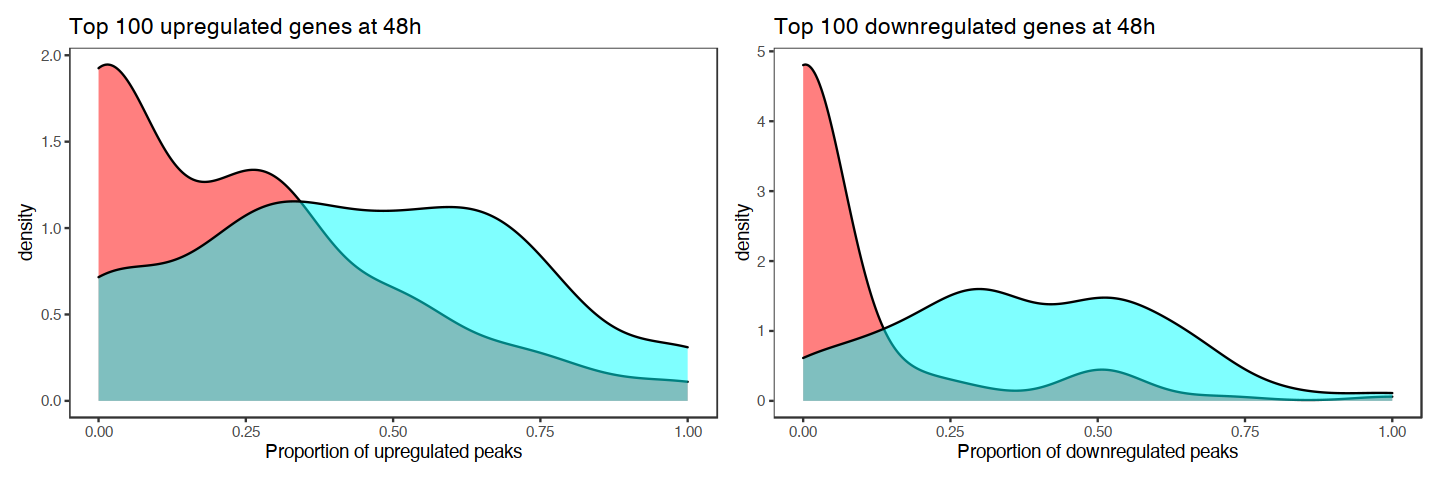

In [89]:
b48_prop = get_prop_up_peaks(b48_dep, "b48_rna_lfc", n = 100, thresh = 1)
e48_prop = get_prop_up_peaks(e48_dep, "e48_rna_lfc", n = 100, thresh = 1)
median(b48_prop$Frac)
median(e48_prop$Frac)
wilcox.test(b48_prop$Frac, e48_prop$Frac)

g1 = ggplot() + geom_density(data = b48_prop, aes(x=Frac), fill="red", alpha=0.5) +
           geom_density(data = e48_prop, aes(x=Frac), fill="cyan", alpha=0.5) +
           ggtitle("Top 100 upregulated genes at 48h") + xlab("Proportion of upregulated peaks") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


b48_prop = get_prop_down_peaks(b48_dep, "b48_rna_lfc", 100, thresh = -1)
e48_prop = get_prop_down_peaks(e48_dep, "e48_rna_lfc", 100, thresh = -1)
median(b48_prop$Frac)
median(e48_prop$Frac)
wilcox.test(b48_prop$Frac, e48_prop$Frac)

g2 = ggplot() + geom_density(data = b48_prop, aes(x=Frac), fill="red", alpha=0.5) +
           geom_density(data = e48_prop, aes(x=Frac), fill="cyan", alpha=0.5) +
           ggtitle("Top 100 downregulated genes at 48h") + xlab("Proportion of downregulated peaks") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())
           
options(repr.plot.width=12, repr.plot.height=4)
g1 + g2


`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



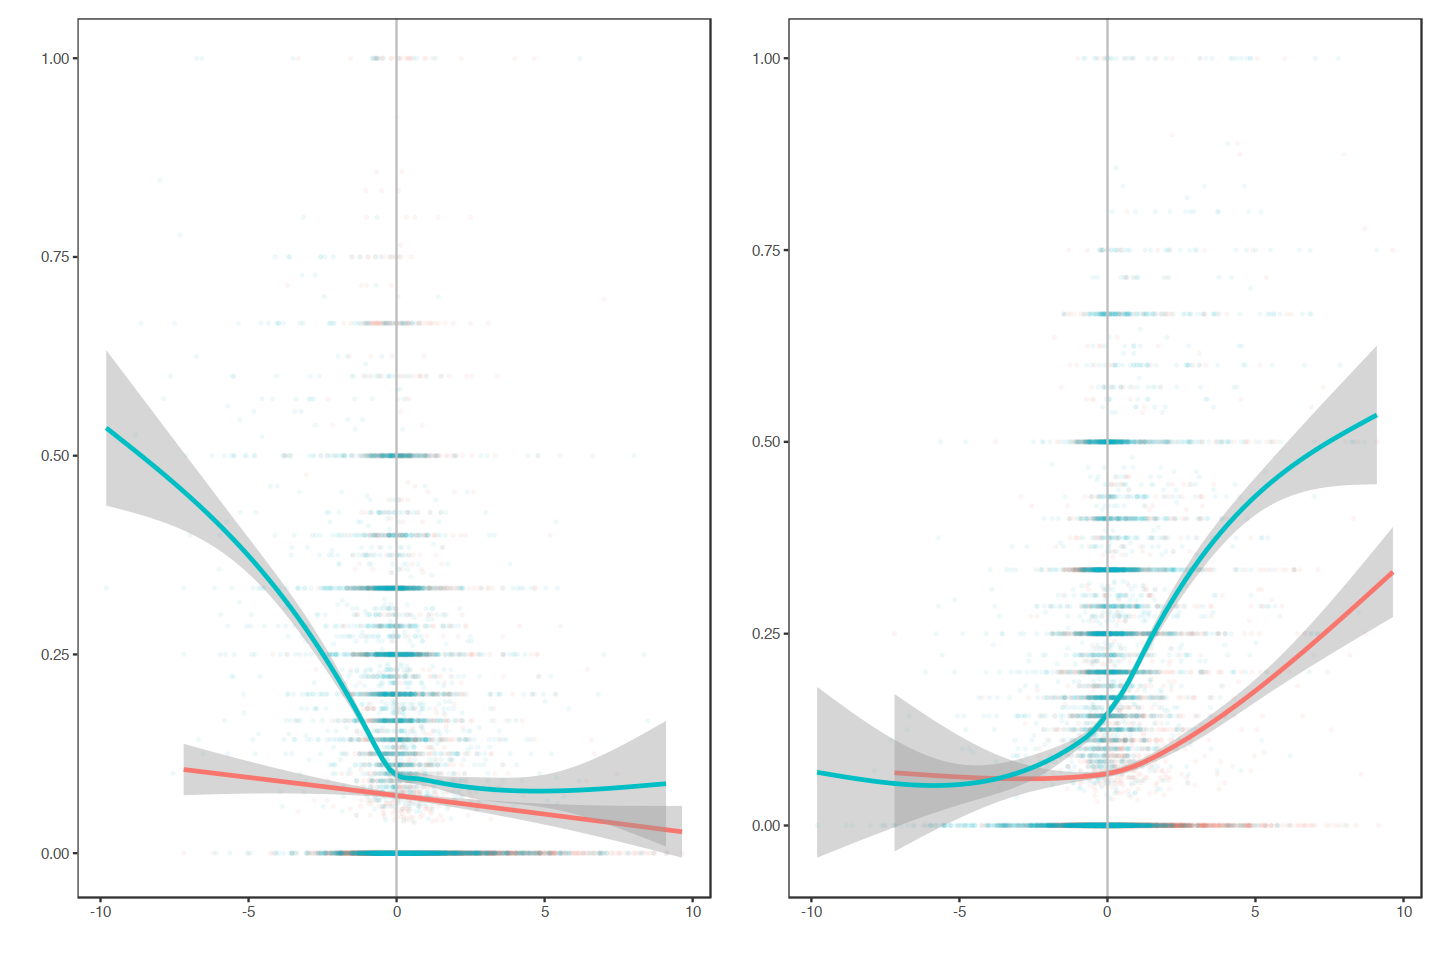

In [26]:
# Plot for all high-complexity genes (48h)
# up peaks
b48_prop_all = get_prop_up_peaks(b48_dep, "b48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
b48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b48_prop_all$gene, ]$b48_rna_lfc
e48_prop_all = get_prop_up_peaks(e48_dep, "e48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
e48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[e48_prop_all$gene, ]$e48_rna_lfc

g1 = ggplot(b48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=e48_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=e48_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g2 = ggplot(e48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

# down peaks
b48_prop_all = get_prop_down_peaks(b48_dep, "b48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
b48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b48_prop_all$gene, ]$b48_rna_lfc
e48_prop_all = get_prop_down_peaks(e48_dep, "e48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
e48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[e48_prop_all$gene, ]$e48_rna_lfc

g3 = ggplot(b48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=e48_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=e48_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g4 = ggplot(e48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("Proportion of peaks") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

options(repr.plot.width=12, repr.plot.height=8)
g3 + g1
# (g3 + g1) / (g4 + g2)
ggsave("../output/220510_all_genes_peaks_scatter48.pdf", width=6, height=3)

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



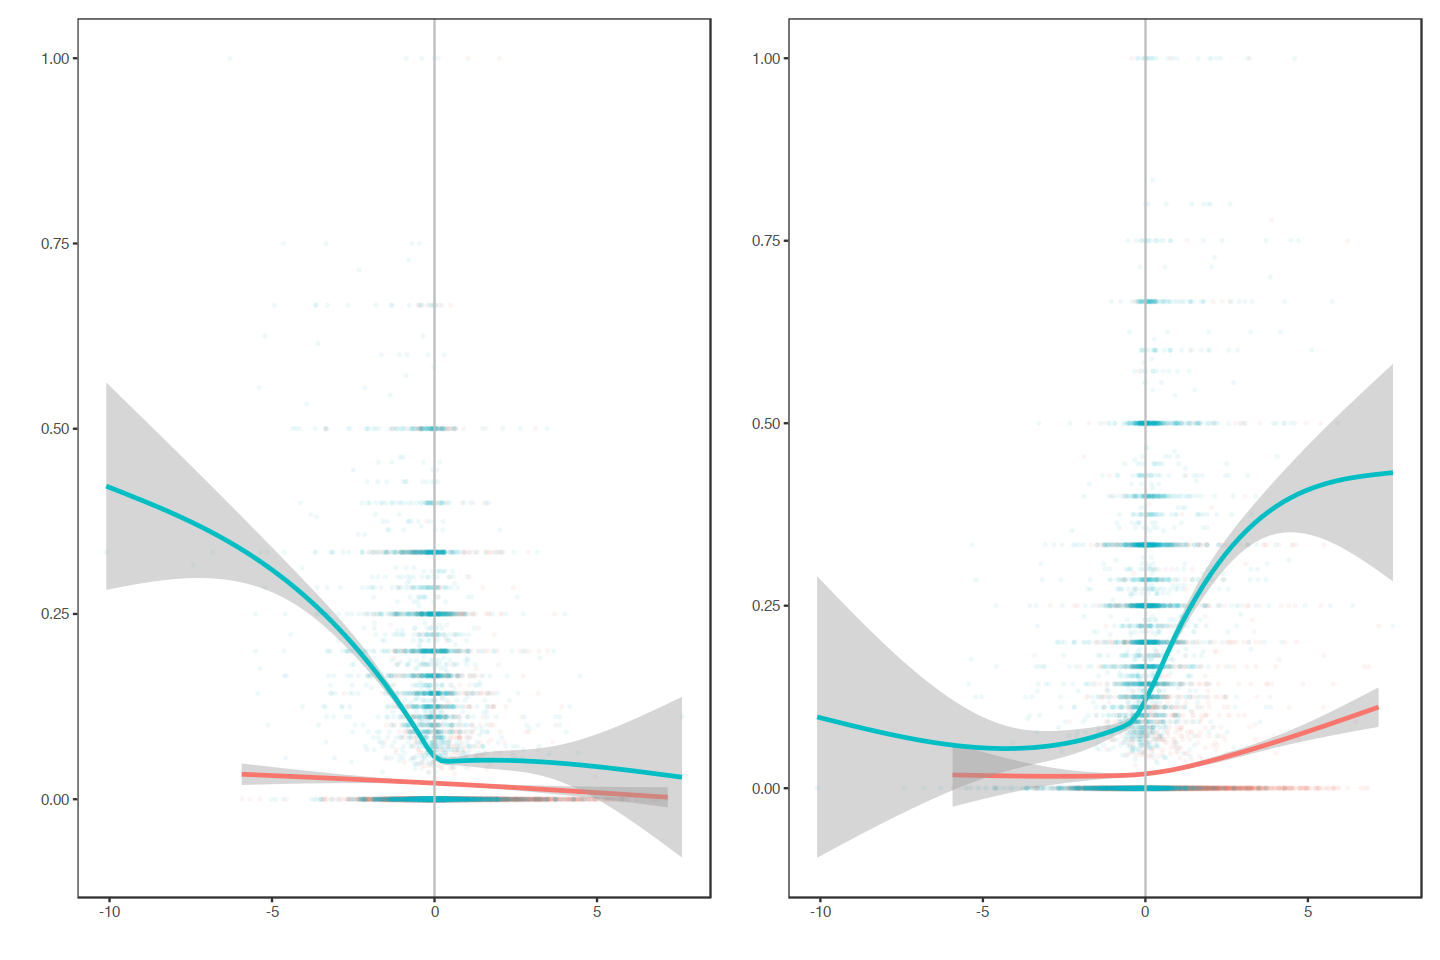

In [27]:
# Plot for all high-complexity genes (24h)
# up peaks
b24_prop_all = get_prop_up_peaks(b24_dep, "b24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
b24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b24_prop_all$gene, ]$b24_rna_lfc
e24_prop_all = get_prop_up_peaks(e24_dep, "e24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
e24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[e24_prop_all$gene, ]$e24_rna_lfc

g1 = ggplot(b24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=e24_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=e24_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g2 = ggplot(e24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

# down peaks
b24_prop_all = get_prop_down_peaks(b24_dep, "b24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
b24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b24_prop_all$gene, ]$b24_rna_lfc
e24_prop_all = get_prop_down_peaks(e24_dep, "e24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
e24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[e24_prop_all$gene, ]$e24_rna_lfc

g3 = ggplot(b24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=e24_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=e24_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g4 = ggplot(e24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("Proportion of peaks") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

options(repr.plot.width=12, repr.plot.height=8)
g3 + g1
# (g3 + g1) / (g4 + g2)
ggsave("../output/220510_all_genes_peaks_scatter24.pdf", width=6, height=3)

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



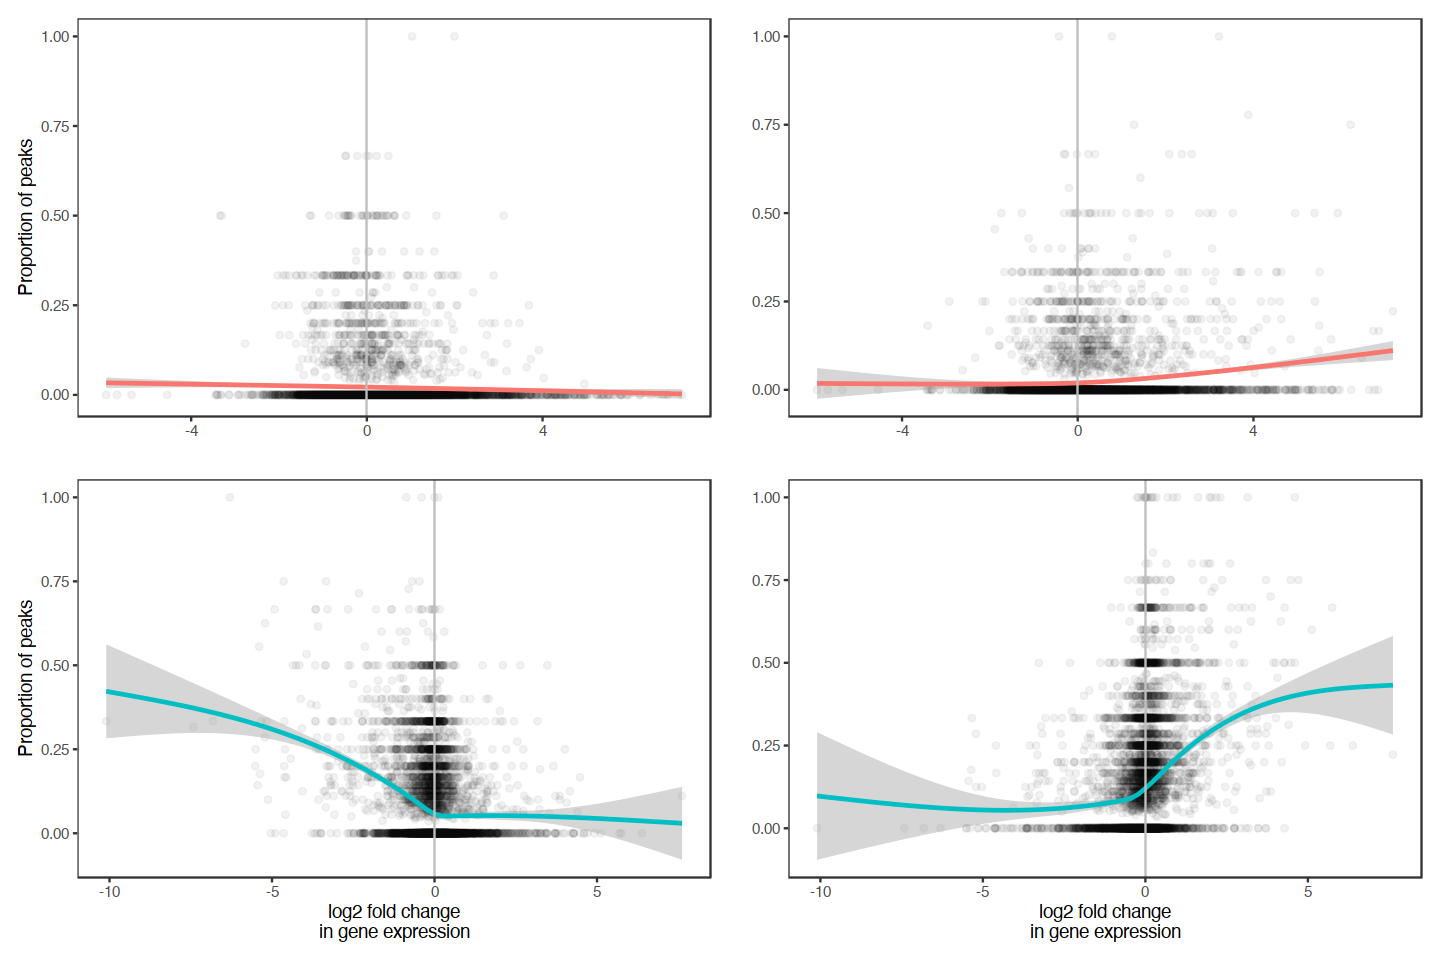

In [59]:
# up peaks
b24_prop_all = get_prop_up_peaks(b24_dep, "b24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
b24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b24_prop_all$gene, ]$b24_rna_lfc
g1 = ggplot(b24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#F8766D") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

e24_prop_all = get_prop_up_peaks(e24_dep, "e24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
e24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[e24_prop_all$gene, ]$e24_rna_lfc
g2 = ggplot(e24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
xlab("log2 fold change\nin gene expression") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

# down peaks
b24_prop_all = get_prop_down_peaks(b24_dep, "b24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
b24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b24_prop_all$gene, ]$b24_rna_lfc
g3 = ggplot(b24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#F8766D") +
xlab("") + ylab("Proportion of peaks") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

e24_prop_all = get_prop_down_peaks(e24_dep, "e24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
e24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[e24_prop_all$gene, ]$e24_rna_lfc
g4 = ggplot(e24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
xlab("log2 fold change\nin gene expression") + ylab("Proportion of peaks") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

options(repr.plot.width=12, repr.plot.height=8)
(g3 + g1) / (g4 + g2)
ggsave("../output/220510_all_genes_peaks_scatter24.pdf", width=6, height=5)

## PU.1 target genes

In [72]:
# https://link.springer.com/article/10.1007%2Fs00005-011-0147-9
pu1_target_genes = 
c("Ccl3", "Ccl5", "Chi3l1", "Cxcl9", "Defa11", "Elane", "Fgl2",
"Igj", "Il12b", "Il18","Il1b", "Il4", "Il9", "Isg15", "Lyz1", "Olfm4", "Ppbp",
"Prg3", "Prtn3", "Tnf", "Tnfsf10", "Bpi", "Cd209", "Cd33", "Cd68", "Cd72",
"Cd79a", "Cd80", "Cd86", "Clec4g", "Clec5a", "Csf1r", "Csf2ra", "Csf2rb",
"Csf3r", "Cxcr1", "Emr1", "Fcer1a", "Fcer2", "Fcgr1a", "Fcgr2b", "Fcgr3a",
"Flt3", "Gpr132", "Il1r1", "Il3ra", "Il7r", "Itgam", "Itgb2", "Lilrb1",
"Ly96", "Mme", "Mrc1", "Mrc1l1", "Ms4a1", "Msr1", "Oprm1", "Oscar", "P2ry10",
"Plin2", "Ptprc", "Tlr4", "Tlr9", "Tnfrsf11a", "Tyrobp", "Acp5", "Aicda",
"Arg1", "Bcl2a1", "Btk", "Ctsk", "Cybb", "Fes", "Ifit3", "Ncf1", "Ncf2",
"Ncf4", "Nf1", "Parg", "Ptpn6", "Rnase2", "Serpinb1", "Tec", "Adar", "Cdk6",
"Cdkn2b", "Ciita", "Ebf1", "Gata1", "Ighmbp2", "Irf4", "Junb", "Klf4", "Lmo2",
"Lyl1", "Mcm3ap", "Mef2c", "Myb", "Nr3c1", "Rel", "Spi1", "Tal1", "Tfec",
"Vav1", "Znf300")

No id variables; using all as measure variables



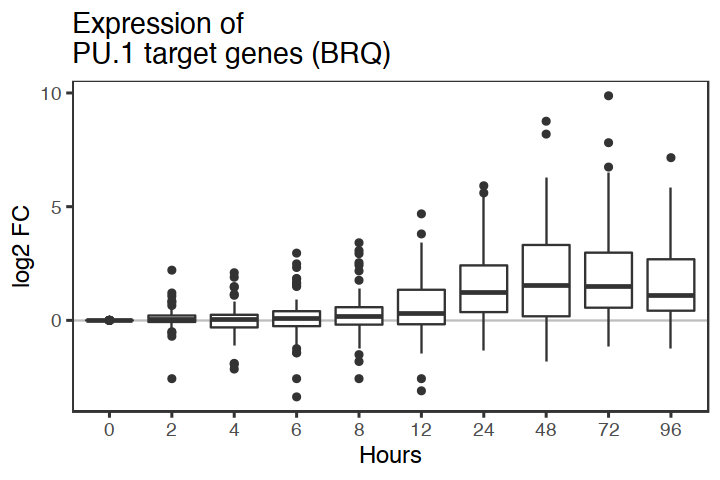

In [101]:
rnaseq_pu1 = rnaseq[intersect(rownames(rnaseq), pu1_target_genes),]

brq_pu1_zero = rnaseq_pu1 - apply(rnaseq_pu1[,1:2], 1, mean)
brq_pu1_mean = (brq_pu1_zero[,(c(1:10) * 2 - 1)] + brq_pu1_zero[,(c(1:10) * 2)])/2
colnames(brq_pu1_mean) = c(0, 2, 4, 6, 8, 12, 24, 48, 72, 96)
brq_pu1_mean_melt = melt(brq_pu1_mean)
options(repr.plot.width = 6, repr.plot.height=4)

ggplot(brq_pu1_mean_melt, aes(x=variable, y=value)) + geom_hline(yintercept = 0, color="gray") +
geom_boxplot() + xlab("Hours") +
ylab("log2 FC") + theme_bw(base_size=14) + theme(panel.grid.major=element_blank(),
panel.grid.minor=element_blank()) + ggtitle("Expression of\nPU.1 target genes (BRQ)")

ggsave("../output/220308_pu1_target_genes.pdf", width=4, height=3)

In [111]:
wilcox.test(brq_pu1_mean[,96])$p.value

ERROR: Error in `[.data.frame`(brq_pu1_mean, , 96): undefined columns selected


In [113]:
pvals = c()
for (i in 1:dim(brq_pu1_mean)[2]) {
    pvals = c(pvals, wilcox.test(brq_pu1_mean[,i])$p.value)
}
pvals

Warning message in wilcox.test.default(brq_pu1_mean[, i]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(brq_pu1_mean[, i]):
“cannot compute exact p-value with zeroes”


[1] 4.759796e-01 3.913767e-02 7.622995e-01 2.981835e-01 5.199712e-02
 [6] 3.202299e-03 1.836298e-10 7.328268e-10 3.481799e-11 1.682390e-11

## Get peak annotations and enrichments

In [30]:
# get GRanges object for all my peaks
peak_ranges = GRanges(seqnames=peak_info$Chr,
                      ranges=IRanges(start=peak_info$Start,
                                     end=peak_info$End),
                      peak_id=rownames(peak_info))
peak_ranges


GRanges object with 123194 ranges and 1 metadata column:
           seqnames            ranges strand |     peak_id
              <Rle>         <IRanges>  <Rle> | <character>
       [1]     chr1   3012381-3012880      * |       peak1
       [2]     chr1   3052495-3053014      * |       peak2
       [3]     chr1   3059480-3059985      * |       peak3
       [4]     chr1   3083075-3083885      * |       peak4
       [5]     chr1   3101039-3101337      * |       peak5
       ...      ...               ...    ... .         ...
  [123190]     chrY 90822548-90822980      * |  peak123190
  [123191]     chrY 90823215-90823775      * |  peak123191
  [123192]     chrY 90824082-90824485      * |  peak123192
  [123193]     chrY 90828762-90829467      * |  peak123193
  [123194]     chrY 90839674-90839930      * |  peak123194
  -------
  seqinfo: 21 sequences from an unspecified genome; no seqlengths

In [31]:
# annotate all 171k peaks
txdb = TxDb.Mmusculus.UCSC.mm10.knownGene
peakAnno <- as.data.frame(annotatePeak(peak_ranges, tssRegion=c(-2000, 500),
                     TxDb=txdb, annoDb="org.Mm.eg.db"))
peakAnno$annobrief = sapply(peakAnno$annotation, function(x) strsplit(x, ' ') [[1]][1])
peakAnno$annobrief[peakAnno$annobrief == "5'"] = "5' UTR"
peakAnno$annobrief[peakAnno$annobrief == "3'"] = "3' UTR"
peakAnno$annobrief[peakAnno$annobrief == "Distal"] = "Intergenic"
peakAnno$annobrief[peakAnno$annobrief == "Downstream"] = "TTS"
head(peakAnno)

>> preparing features information...		 2022-05-10 23:11:19 
>> identifying nearest features...		 2022-05-10 23:11:20 
>> calculating distance from peak to TSS...	 2022-05-10 23:11:23 
>> assigning genomic annotation...		 2022-05-10 23:11:23 
>> adding gene annotation...			 2022-05-10 23:11:43 


Loading required package: org.Mm.eg.db



'select()' returned 1:many mapping between keys and columns



>> assigning chromosome lengths			 2022-05-10 23:11:43 
>> done...					 2022-05-10 23:11:43 


,seqnames,start,end,width,strand,peak_id,annotation,geneChr,geneStart,geneEnd,geneLength,geneStrand,geneId,transcriptId,distanceToTSS,ENSEMBL,SYMBOL,GENENAME,annobrief
,<fct>,<int>,<int>,<int>,<fct>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,chr1,3012381,3012880,500,*,peak1,Distal Intergenic,1,3214482,3671498,457017,2,497097,ENSMUST00000070533.4,658618,ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,Intergenic
2,chr1,3052495,3053014,520,*,peak2,Distal Intergenic,1,3214482,3671498,457017,2,497097,ENSMUST00000070533.4,618484,ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,Intergenic
3,chr1,3059480,3059985,506,*,peak3,Distal Intergenic,1,3214482,3671498,457017,2,497097,ENSMUST00000070533.4,611513,ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,Intergenic
4,chr1,3083075,3083885,811,*,peak4,Distal Intergenic,1,3214482,3671498,457017,2,497097,ENSMUST00000070533.4,587613,ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,Intergenic
5,chr1,3101039,3101337,299,*,peak5,Distal Intergenic,1,3214482,3671498,457017,2,497097,ENSMUST00000070533.4,570161,ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,Intergenic
6,chr1,3104799,3105370,572,*,peak6,Distal Intergenic,1,3214482,3671498,457017,2,497097,ENSMUST00000070533.4,566128,ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,Intergenic


In [32]:
# Get baseline frequency across the genome

baseline_freqs = data.frame(table(peakAnno[which(peakAnno$peak_id %in% rownames(b48_dep)),]$annobrief))
baseline_cts = baseline_freqs
baseline_freqs$Freq = baseline_freqs$Freq/sum(baseline_freqs$Freq)*100
baseline_freqs

Var1,Freq
<fct>,<dbl>
3' UTR,2.7497598
5' UTR,0.4202690
Exon,6.4085014
Intergenic,32.9598943
Intron,35.7468780
Promoter,21.5297791
TTS,0.1849183


In [33]:
# Get frequency and counts for 24h and 48h

res = b48_dep
up_peaks_brq = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_brq = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_brq),]$annobrief))$Freq
baseline_freqs$b48_up = up_freq/sum(up_freq)*100
baseline_cts$b48_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_brq),]$annobrief))$Freq
baseline_freqs$b48_down = down_freq/sum(down_freq)*100
baseline_cts$b48_down = down_freq

baseline_cts$b48 = up_freq + down_freq
baseline_freqs$b48  = baseline_cts$b48/sum(baseline_cts$b48) * 100

res = e48_dep
up_peaks_e2w = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_e2w = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_e2w),]$annobrief))$Freq
baseline_freqs$e48_up = up_freq/sum(up_freq)*100
baseline_cts$e48_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_e2w),]$annobrief))$Freq
baseline_freqs$e48_down = down_freq/sum(down_freq)*100
baseline_cts$e48_down = down_freq

baseline_cts$e48 = up_freq + down_freq
baseline_freqs$e48  = baseline_cts$e48/sum(baseline_cts$e48) * 100

res = b24_dep
up_peaks_brq = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_brq = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_brq),]$annobrief))$Freq
baseline_freqs$b24_up = up_freq/sum(up_freq)*100
baseline_cts$b24_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_brq),]$annobrief))$Freq
baseline_freqs$b24_down = down_freq/sum(down_freq)*100
baseline_cts$b24_down = down_freq

baseline_cts$b24 = up_freq + down_freq
baseline_freqs$b24  = baseline_cts$b24/sum(baseline_cts$b24) * 100

res = e24_dep
up_peaks_e2w = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_e2w = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_e2w),]$annobrief))$Freq
baseline_freqs$e24_up = up_freq/sum(up_freq)*100
baseline_cts$e24_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_e2w),]$annobrief))$Freq
baseline_freqs$e24_down = down_freq/sum(down_freq)*100
baseline_cts$e24_down = down_freq

baseline_cts$e24 = up_freq + down_freq
baseline_freqs$e24  = baseline_cts$e24/sum(baseline_cts$e24) * 100


rownames(baseline_freqs) = baseline_freqs$Var1
rownames(baseline_cts) = baseline_freqs$Var1
baseline_freqs = baseline_freqs[,2:dim(baseline_freqs)[2]]
baseline_cts = baseline_cts[,2:dim(baseline_cts)[2]]

baseline_freqs
baseline_cts

,Freq,b48_up,b48_down,b48,e48_up,e48_down,e48,b24_up,b24_down,b24,e24_up,e24_down,e24
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3' UTR,2.7497598,1.7923036,6.2391681,2.8294260,2.7136727,3.1418200,2.9195762,1.4336918,4.6153846,2.3235800,2.7172196,3.5190616,3.0320476
5' UTR,0.4202690,0.2108593,0.3466205,0.2425222,0.2203409,0.4881712,0.3491452,0.2389486,0.3076923,0.2581756,0.1421801,0.3421310,0.2206870
Exon,6.4085014,4.8234054,10.3119584,6.1034762,6.5406471,7.1097759,6.8143511,4.1816010,10.7692308,6.0240964,6.0979463,7.8690127,6.7933218
Intergenic,32.9598943,47.8123353,23.0502600,42.0371867,35.4401021,36.8256352,36.1064291,54.2413381,29.2307692,47.2461274,37.2827804,34.6041056,36.2310497
Intron,35.7468780,40.8803374,39.6880416,40.6022635,46.7818625,43.0091376,44.9674934,36.2007168,42.4615385,37.9518072,46.1611374,44.1348974,45.3655728
Promoter,21.5297791,4.3753295,20.0173310,8.0234438,8.1758089,9.2126674,8.6744522,3.5842294,12.0000000,5.9380379,7.4565561,9.3597263,8.2037997
TTS,0.1849183,0.1054296,0.3466205,0.1616815,0.1275658,0.2127926,0.1685529,0.1194743,0.6153846,0.2581756,0.1421801,0.1710655,0.1535214


,Freq,b48_up,b48_down,b48,e48_up,e48_down,e48,b24_up,b24_down,b24,e24_up,e24_down,e24
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
3' UTR,2290,68,72,140,234,251,485,12,15,27,172,144,316
5' UTR,350,8,4,12,19,39,58,2,1,3,9,14,23
Exon,5337,183,119,302,564,568,1132,35,35,70,386,322,708
Intergenic,27449,1814,266,2080,3056,2942,5998,454,95,549,2360,1416,3776
Intron,29770,1551,458,2009,4034,3436,7470,303,138,441,2922,1806,4728
Promoter,17930,166,231,397,705,736,1441,30,39,69,472,383,855
TTS,154,4,4,8,11,17,28,1,2,3,9,7,16


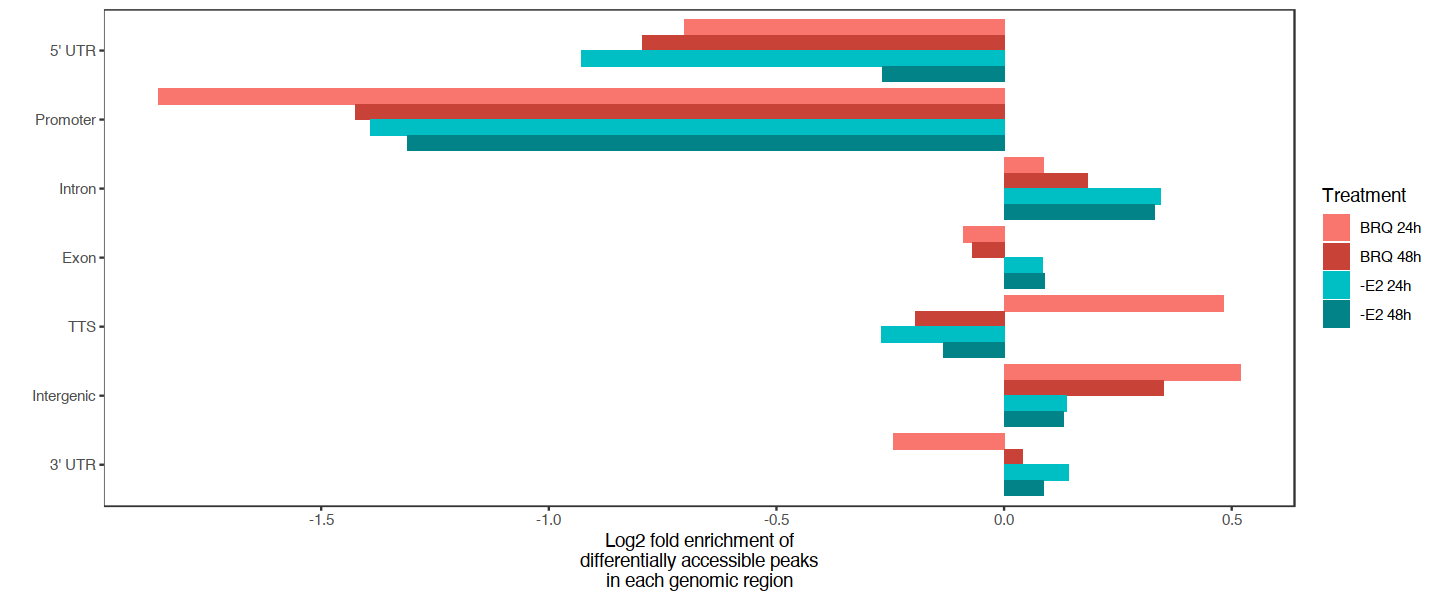

In [35]:
log2_region_changes = log2(with(baseline_freqs, cbind(b24/Freq, b48/Freq, e24/Freq, e48/Freq)))
rownames(log2_region_changes) = rownames(baseline_freqs)
colnames(log2_region_changes) = c("BRQ 24h", "BRQ 48h", "-E2 24h", "-E2 48h")
log2_region_changes_m = melt(log2_region_changes)
colnames(log2_region_changes_m) = c("Region", "Treatment", "log2fc")
log2_region_changes_m$Region = factor(log2_region_changes_m$Region, levels=
rev(c("5' UTR", "Promoter", "Intron", "Exon", "TTS", "Intergenic", "3' UTR")))
log2_region_changes_m$Treatment = factor(log2_region_changes_m$Treatment, levels=rev(c("BRQ 24h", "BRQ 48h", "-E2 24h", "-E2 48h")))

ggplot(data = log2_region_changes_m, aes(x=Region, y=log2fc, fill=Treatment)) + 
geom_col(position = "dodge") + theme_bw() + theme(panel.grid.major = element_blank(),
panel.grid.minor = element_blank()) + coord_flip() + geom_vline(xintercept=0) +
ylab("Log2 fold enrichment of\ndifferentially accessible peaks\nin each genomic region") +
xlab("") + scale_fill_manual(values = c("BRQ 24h" = "#F8766D",
                                "BRQ 48h"="#c94238",
                                "-E2 24h"="#00BFC4",
                                "-E2 48h"="#018388")) 

ggsave("../output/220226_633_atac_dapeaks_enrichment.pdf", width=4, height=4)

## ChromVAR plot

In [ ]:
library(chromVAR)
library(motifmatchr)
library(chromVARmotifs)
library(Matrix)
library(SummarizedExperiment)
library(BiocParallel)
library(BSgenome.Mmusculus.UCSC.mm10)
register(MulticoreParam(4, progressbar = TRUE))
set.seed(2017)

In [ ]:
# use normalized peak counts -- 

peaks = makeGRangesFromDataFrame(peak_info[rownames(norm_expr),1:4])

df_reordered = df[,c(1,2,11:14,3:10,
                         15:16,27,28,31,32,19:26,29,30,33,34,17,18)]  # re-order 
count_matrix_brq = as.matrix(df_reordered[rownames(norm_expr),1:14])
count_matrix_e2w = as.matrix(df_reordered[rownames(norm_expr),15:30])
count_matrix = as.matrix(df_reordered[rownames(norm_expr),1:28])

# fragment_counts_brq = SummarizedExperiment(assays = list(counts = count_matrix_brq),
#                                        rowRanges = peaks)
# fragment_counts_e2w = SummarizedExperiment(assays = list(counts = count_matrix_e2w),
#                                                          rowRanges = peaks)
fragment_counts = SummarizedExperiment(assays = list(counts = count_matrix),
                                                         rowRanges = peaks)

In [ ]:
# add GC bias
# fragment_counts_brq <- addGCBias(fragment_counts_brq, genome = BSgenome.Mmusculus.UCSC.mm10)
# fragment_counts_e2w <- addGCBias(fragment_counts_e2w, genome = BSgenome.Mmusculus.UCSC.mm10)
fragment_counts <- addGCBias(fragment_counts, genome = BSgenome.Mmusculus.UCSC.mm10)

# get motifs
# jaspar_motifs <- getJasparMotifs()
data("mouse_pwms_v2") # mouse collection from greenleaf lab

In [ ]:
get_deviations = function(data, motif_set) {
  motif_ix <- matchMotifs(motif_set, data,  genome = BSgenome.Mmusculus.UCSC.mm10)
  dev <- computeDeviations(object = data, annotations = motif_ix)
  return(dev)
}

# ordered by variability
get_values = function(data, dev, column_names, num_motifs=-1, pct=FALSE) {
  dev_deviations = deviations(dev)
  dev_zsc = deviationScores(dev)
  
  variability <- computeVariability(dev)
  
  if(num_motifs == -1) num_motifs = dim(variability)[1]
  highly_variable = variability[order(-variability[,"variability"]),][1:num_motifs,]
  dev_highvar = dev_deviations[rownames(highly_variable),]
  colnames(dev_highvar)= column_names
  if(!pct) return(dev_highvar)

  #rownames(dev_highvar) = highly_variable$name
  dev_highvar_pct = t(apply(dev_highvar,1,function(x) (x - min(x))/(max(x) - min(x))))
  return(dev_highvar_pct)
}

# ordered by when the motif is maximallly open
order_by_max = function(dev) {
  dev_order = apply(dev,1,which.max)
  return(dev[order(dev_order),])
}

melt_df = function(data) {
  dev_highvar_melt = melt(data)
  colnames(dev_highvar_melt) = c("Motif", "Timepoint", "Pct")
  return(dev_highvar_melt)
}

chname = function(x) {
  x = sub("XP_", "XP", x)
  x = sub("NP_", "NP", x)
  return(x)
}


In [ ]:
# brq mouse
brq_cols = c("0_1", "0_2", "4_1", "4_2", "8_1", "8_2", 
             "12_1", "12_2", "24_1", "24_2", "36_1", "36_2", "48_1", "48_2")
dev_brq_mouse = get_deviations(fragment_counts_brq, mouse_pwms_v2)
dev_brq_mouse_vals = get_values(fragment_counts_brq, dev_brq_mouse, brq_cols, pct=FALSE)
dev_brq_mouse_pct = get_values(fragment_counts_brq, dev_brq_mouse, brq_cols, pct=TRUE)
rownames(dev_brq_mouse_pct) = sapply(rownames(dev_brq_mouse_pct), 
                                     function(x) {strsplit(chname(x), '_')[[1]][3]})
rownames(dev_brq_mouse_vals) = sapply(rownames(dev_brq_mouse_vals), 
                                      function(x) {strsplit(chname(x), '_')[[1]][3]})
dev_brq_mouse_pct = dev_brq_mouse_pct[!duplicated(rownames(dev_brq_mouse_pct)),]
dev_brq_mouse_vals = dev_brq_mouse_vals[!duplicated(rownames(dev_brq_mouse_vals)),]

write.table(dev_brq_mouse_vals, "../output/210629_brq_chromvar_mouse.csv", sep=',', quote=FALSE)


In [ ]:
# e2 mouse
e2w_cols = c("0_1", "0_2", "4_1", "4_2", "8_1", "8_2", 
             "12_1", "12_2", "24_1", "24_2", "36_1", "36_2", 
             "48_1", "48_2")
dev_e2w_mouse = get_deviations(fragment_counts_e2w, mouse_pwms_v2)
dev_e2w_mouse_vals = get_values(fragment_counts_e2w, dev_e2w_mouse, e2w_cols, pct=FALSE)
dev_e2w_mouse_pct = get_values(fragment_counts_e2w, dev_e2w_mouse, e2w_cols, pct=TRUE)
rownames(dev_e2w_mouse_pct) = sapply(rownames(dev_e2w_mouse_pct), 
                                     function(x) {strsplit(chname(x), '_')[[1]][3]})
rownames(dev_e2w_mouse_vals) = sapply(rownames(dev_e2w_mouse_vals), 
                                      function(x) {strsplit(chname(x), '_')[[1]][3]})
dev_e2w_mouse_pct = dev_e2w_mouse_pct[!duplicated(rownames(dev_e2w_mouse_pct)),]
dev_e2w_mouse_vals = dev_e2w_mouse_vals[!duplicated(rownames(dev_e2w_mouse_vals)),]
write.table(dev_e2w_mouse_vals, "../output/210629_e2w_chromvar_mouse.csv", sep=',', quote=FALSE)


In [ ]:
# all mouse
dev_mouse = get_deviations(fragment_counts, mouse_pwms_v2)
dev_mouse_vals = get_values(fragment_counts, dev_mouse, c(brq_cols, e2w_cols), pct=FALSE)
dev_mouse_pct = get_values(fragment_counts, dev_mouse, c(brq_cols, e2w_cols), pct=TRUE)
rownames(dev_mouse_pct) = sapply(rownames(dev_mouse_pct), 
                                     function(x) {strsplit(chname(x), '_')[[1]][3]})
rownames(dev_mouse_vals) = sapply(rownames(dev_mouse_vals), 
                                      function(x) {strsplit(chname(x), '_')[[1]][3]})
dev_mouse_pct = dev_mouse_pct[!duplicated(rownames(dev_mouse_pct)),]
dev_mouse_vals = dev_mouse_vals[!duplicated(rownames(dev_mouse_vals)),]

write.table(dev_mouse_vals, "../output/210629_all_chromvar_mouse.csv", sep=',', quote=FALSE)


Warning message:
“The input is a data frame, convert it to a matrix.”


pdf 
  2

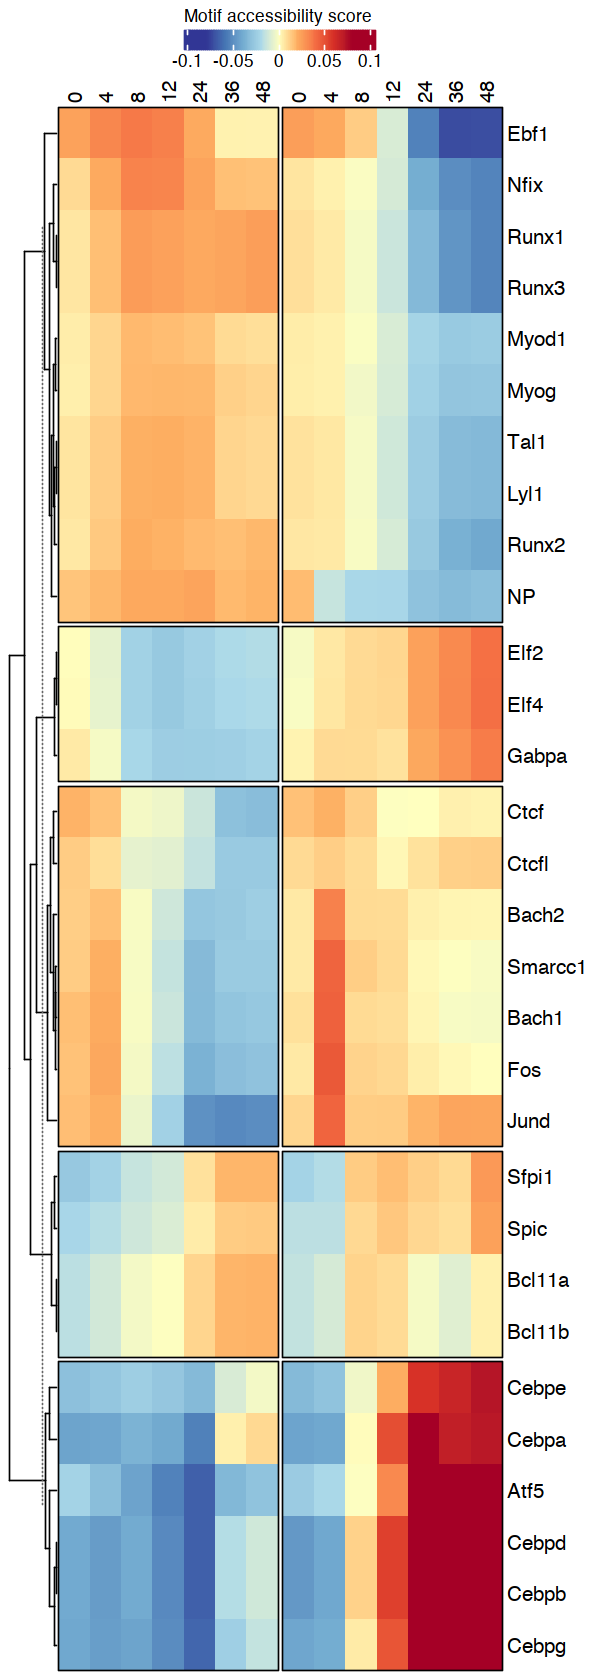

In [8]:
# Plotting top 30 motifs 
options(repr.plot.width=5, repr.plot.height=14)

dev_mouse_vals = read.csv("../data/210629_all_chromvar_mouse.csv")

dev_mouse_vals_mean = (dev_mouse_vals[,(c(1:14)*2 - 1)] + dev_mouse_vals[,(c(1:14)*2)])/2
colnames(dev_mouse_vals_mean) = c(0, 4, 8, 12, 24, 36, 48, 0, 4, 8, 12, 24, 36, 48)
h = Heatmap(head(dev_mouse_vals_mean,30), 
        cluster_columns = F, 
        # cluster_rows = F,
        column_names_side = "top", 
        column_title=NULL,
        row_title=NULL,
        border=T,
        row_km=6, row_km_repeats = 100,
        column_split = c(rep("BRQ", 7), rep("E2", 7)),
        col = colorRamp2(seq(-0.08, 0.08, length.out = 9), 
                         rev(RColorBrewer::brewer.pal(name = "RdYlBu", n = 11))[c(1:4, 6, 8:11)]),
       heatmap_legend_param = list(title="Motif accessibility score",
                                   direction="horizontal"))

draw(h, heatmap_legend_side="top")


pdf("../output/220608_633_atac_top30.pdf", width=4, height=6)
draw(h, heatmap_legend_side="bottom")
dev.off()
